# **Socio-Economic Features:**   

9. **wealth_index** - {Poorest, Poorer, Middle, Richer, Richest}
   - Distribution from NDHS wealth quintiles
   
10. **monthly_household_income** - Continuous (NPR 10,000 - 150,000)
    - Log-normal distribution, correlated with wealth_index
    
11. **food_security** - {Secure, Mildly insecure, Moderately insecure, Severely insecure}
    - Correlated with wealth and residence
    
12. **housing_quality** - Score 1-10
    - Based on materials, rooms, facilities
    
13. **financial_stress_level** - Score 0-10
    - Negatively correlated with income

-----

#### **wealth_index**  
- **Distribution:** NDHS wealth index divides households into 5 equal groups (quintiles):  
    - Poorest: **20.1%**  
    - Poorer: **20.1%**  
    - Middle: **20.2%**  
    - Richer: **19.7%**  
    - Richest: **19.7%**  
- **Associated with:** Region, urban/rural, education, food security, housing, income.
- Poorest quintiles concentrated in rural & disadvantaged provinces, highest in urban Bagmati, Koshi, Gandaki.

#### **monthly_household_income**  
- **Range:** Typically NPR **10,000–150,000** per month (highly skewed).
- **Median:** NPR **25,000–30,000**; **mean:** NPR **42,000–55,000** (urban mean is higher).
- **Distribution:** **Log-normal**—majority below NPR 50,000; <5% households >NPR 100,000.
- **Strong correlation** with wealth index. Richest = higher income, Poorest = lowest

#### **food_security**  
- **Prevalence (NDHS/FAO):**  
    - Secure: **48%**
    - Mildly insecure: **20%**
    - Moderately insecure: **22%**
    - Severely insecure: **10%**
- Strongly **correlated with wealth, residence, and region**—rural poor more likely to be insecure.
- Provinces: Karnali, Sudurpashchim highest insecurity; Gandaki, Kathmandu lowest.

#### **housing_quality**  
- **Index (1–10):** Based on floor/wall/roof material, # rooms, sanitation, electricity, assets.
    - **Mean:** ~6.1 (urban) vs. ~4.3 (rural).
    - **Poorest quintile:** Avg = 3–5
    - **Richest quintile:** Avg = 7–9
- **Correlated** with wealth index and urban residence.[2][8]
- High-quality housing rare in poorest; urban & richest quintiles mostly score >7.

#### **financial_stress_level**  
- **Index (0–10):** Measures how stressed families are financially.
    - **Inverse correlation** with income: Poorest/lowest income report scores 7–10.
    - **About 30% of Nepali households report “high financial stress” (score ≥7),** with only 15% of richest quintile scoring >5.
    - Urbanization, income stability, savings, remittance decrease stress.

### **Relation Mapping and Joint Patterns**

| Main Variable           | Strongly Related/Correlated With                     | NDHS/WHO/Research Patterns                                                                                                     |
|-------------------------|------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------|
| **wealth_index**        | income, housing_quality, food_security, province     | Higher wealth = higher income, less food insecurity, better housing, urban provinces more likely to be richer                  |
| **monthly_income**      | wealth_index, urban residence, province              | Direct relation with wealth; urban and central provinces (Bagmati) have higher incomes                                        |
| **food_security**       | wealth_index, income, residence, province            | Poorest → more insecurity; rural & Karnali/Sudurpashchim have high risk; middle/rich urban secure                            |
| **housing_quality**     | wealth_index, residence, province                    | Higher in richer, urban/quasi-urban settings; provinces with city clusters high; poorest rural low                           |
| **financial_stress**    | income, wealth_index, food_security                  | Poorest/lowest income families most stressed; high wealth/income = low stress; food insecure and rural increases stress      |

- **wealth_index** → monthly_income (strong)
- **wealth_index, income** → housing_quality (positive)
- **wealth/income** & residence/province → food security (higher in poor/rural/provinces)
- **income** → financial stress (negative; higher income lowers stress)
- **food_security** → financial stress (positive; insecurity raises stress)


### **Summary Table for Mapping Features**

| wealth_index   | income   | food_security   | housing_quality | financial_stress |
|----------------|----------|----------------|-----------------|------------------|
| Poorest        | low      | moderate/severe| 3–5             | 8–10             |
| Poorer         | low      | mild/moderate  | 4–6             | 7–9              |
| Middle         | mid      | mildly insecure| 5–7             | 4–7              |
| Richer         | high     | mostly secure  | 7–9             | 2–5              |
| Richest        | highest  | secure         | 8–10            | 0–3              |


---
---
-----
----

## **Data Generation:**

In [2]:
import numpy as np
import pandas as pd

n_samples = 15000

# NDHS 2022 proportions and realistic values
wealth_categories = ['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest']
wealth_probs =      [0.202,   0.202,   0.202,   0.197,    0.197]

# Income bounds (NPR)
income_bounds = {
    'Poorest':  (10000, 25000),
    'Poorer':   (15000, 35000),
    'Middle':   (20000, 65000),
    'Richer':   (35000, 100000),
    'Richest':  (60000, 150000)
}

# Food security by wealth (NDHS, FAO, UN)
food_map = {
    'Poorest':      ['Severe',   'Moderate', 'Mild',  'Secure'],
    'Poorer':       ['Moderate', 'Mild',     'Secure', 'Severe'],
    'Middle':       ['Mild',     'Secure',   'Moderate', 'Severe'],
    'Richer':       ['Secure',   'Mild',     'Moderate', 'Severe'],
    'Richest':      ['Secure',   'Mild',     'Moderate', 'Severe']
}
food_probs_map = {
    'Poorest':      [0.28, 0.31, 0.26, 0.15],
    'Poorer':       [0.15, 0.28, 0.44, 0.13],
    'Middle':       [0.08, 0.21, 0.63, 0.08],
    'Richer':       [0.02, 0.10, 0.84, 0.04],
    'Richest':      [0.01, 0.08, 0.87, 0.04]
}

# Housing quality by wealth/quintile
housing_base = {
    'Poorest':  (3.0, 1.2),
    'Poorer':   (4.5, 1.1),
    'Middle':   (6.0, 1.1),
    'Richer':   (8.0, 1.2),
    'Richest':  (9.0, 0.7)
}

# Financial stress by income
def financial_stress(income):
    # NPR bands; higher income = lower stress, random noise added
    if income < 18000:
        return np.clip(np.random.normal(9, 0.8), 7, 10)
    elif income < 35000:
        return np.clip(np.random.normal(7, 1.2), 4, 9)
    elif income < 60000:
        return np.clip(np.random.normal(5.2, 1.1), 2, 8)
    elif income < 100000:
        return np.clip(np.random.normal(3.2, 1.0), 0, 6)
    else:
        return np.clip(np.random.normal(1.5, 0.7), 0, 5)

data = []
for i in range(n_samples):
    # 1. Wealth index by NDHS quintiles
    wealth = np.random.choice(wealth_categories, p=wealth_probs)
    
    # 2. Household income, log-normal within each quintile
    low, high = income_bounds[wealth]
    log_mean = np.log((low + high)/2)
    log_std = 0.35  # realistic spread
    income = int(np.clip(np.random.lognormal(log_mean, log_std), low, high))
    
    # 3. Food security: odds depend on wealth, with some randomization
    foodchoices = food_map[wealth]
    foodprobs   = food_probs_map[wealth]
    food_sec = np.random.choice(foodchoices, p=foodprobs)
    # Relabels for standard scale
    food_dict = {'Secure':'Secure', 'Mild':'Mildly insecure', 'Moderate':'Moderately insecure', 'Severe':'Severely insecure'}
    food_sec_label = food_dict.get(food_sec, food_sec)
    
    # 4. Housing quality (score 1-10): wealth-linked, with some noise
    h_mean, h_std = housing_base[wealth]
    housing = int(np.clip(np.random.normal(h_mean, h_std), 1, 10))
    
    # 5. Financial stress level: mainly determined by income
    stress = int(round(financial_stress(income)))
    
    data.append([wealth, income, food_sec_label, housing, stress])

columns = ['wealth_index', 'monthly_household_income', 'food_security',
           'housing_quality', 'financial_stress_level']
df = pd.DataFrame(data, columns=columns)

In [4]:
df.head()

,wealth_index,monthly_household_income,food_security,housing_quality,financial_stress_level
0,Richer,87619,Secure,9,3
1,Middle,43019,Moderately insecure,6,5
2,Poorest,19715,Moderately insecure,3,9
3,Poorer,31695,Severely insecure,5,8
4,Richest,128609,Moderately insecure,10,1


In [13]:
df["food_security"].value_counts()

food_security
Moderately insecure    8307
Secure                 2506
Mildly insecure        2442
Severely insecure      1745
Name: count, dtype: int64

In [5]:
import matplotlib.pyplot as plt 
import seaborn as sns

<Axes: xlabel='wealth_index', ylabel='monthly_household_income'>

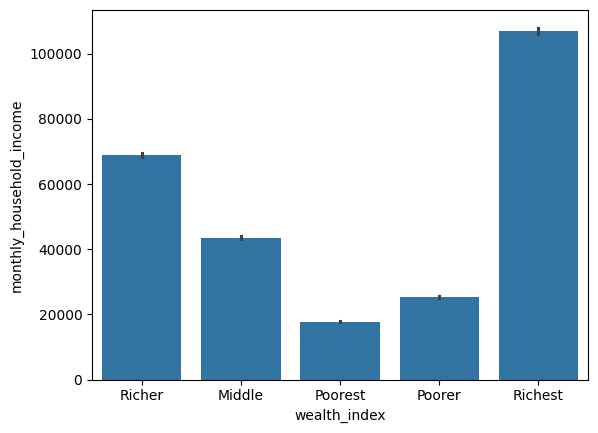

In [7]:
sns.barplot(data= df, x= "wealth_index", y= "monthly_household_income")

In [14]:
df.describe()

,monthly_household_income,housing_quality,financial_stress_level
count,15000.000000,15000.000000,15000.0000
mean,51711.638267,5.557200,5.3412
std,36551.641514,2.428893,2.5959
min,10000.000000,1.000000,0.0000
25%,22644.000000,4.000000,3.0000
50%,38234.000000,5.000000,5.0000
75%,71018.000000,8.000000,7.0000
max,150000.000000,10.000000,10.0000


<Axes: >

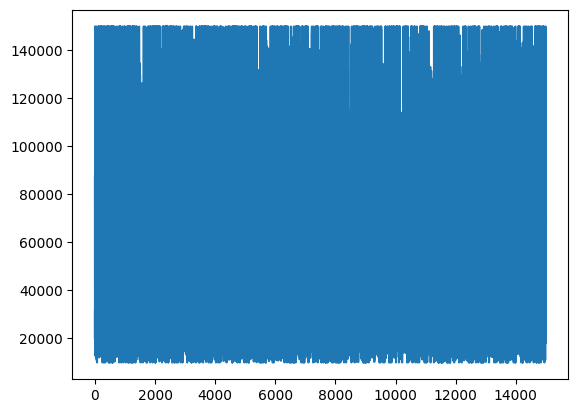

In [17]:
df["monthly_household_income"].plot(kind= "line")

In [ ]:
# Save dataset
df.to_csv('synthetic_nepal_socioeconomic_features.csv', index=False)

- **wealth_index** drives all other features—income, food security, housing, and stress.

- **monthly_household_income** is log-normal and banded by wealth.

- **food_security** uses published probabilities for each wealth group.

- **housing_quality** higher with wealth, score based on NDHS material/
facility summaries.

- **financial_stress_level** is critically inverse to income—a well-mapped NDHS/WHO relationship.